# Airbnb Superhost Prediction Using Logistic Regression
This project develops a machine learning classification model to predict whether an Airbnb host is a Superhost. The workflow includes data preparation, logistic regression, hyperparameter tuning, model evaluation, feature selection, and model persistence.


In [13]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [14]:
df = pd.read_csv("airbnbData_train.csv")


## Features & Target


In [15]:
y = df["host_is_superhost"]
X = df.drop(columns="host_is_superhost")

## Train-Test Split


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.10, random_state=1234)

## Baseline Model




In [17]:
model_default = LogisticRegression(max_iter=1000)
model_default.fit(X_train, y_train);

In [18]:

proba_predictions_default = model_default.predict_proba(X_test)[:,1]


class_label_predictions_default = model_default.predict(X_test)

In [19]:
cm = confusion_matrix(y_test,class_label_predictions_default)

## Hyperparameter Tuning



In [42]:
cs=[10**i for i in range(-5,5)]
param_grid = {"C" : cs}


In [21]:
print('Running Grid Search...')

model = LogisticRegression(max_iter = 1000)

grid = GridSearchCV(model,param_grid,cv=5)

grid_search = grid.fit(X_train, y_train)
print('Done')

Running Grid Search...
Done


In [22]:
best_C = grid_search.best_params_["C"]
best_C

1000

## Optimized Model


In [23]:
model_best = LogisticRegression(C=best_C, max_iter = 1000)
model_best.fit(X_train, y_train);

In [ ]:
proba_predictions_best = model_best.predict_proba(X_test)[:,1]
class_label_predictions_best = model_best.predict(X_test)

In [25]:
cm_best = confusion_matrix(y_test,class_label_predictions_best)

## Precision-Recall Curve

In [26]:
from sklearn.metrics import precision_recall_curve

In [27]:
precision_default, recall_default, thresholds_default = precision_recall_curve(y_test, proba_predictions_default)
precision_best, recall_best, thresholds_best = precision_recall_curve(y_test, proba_predictions_best)

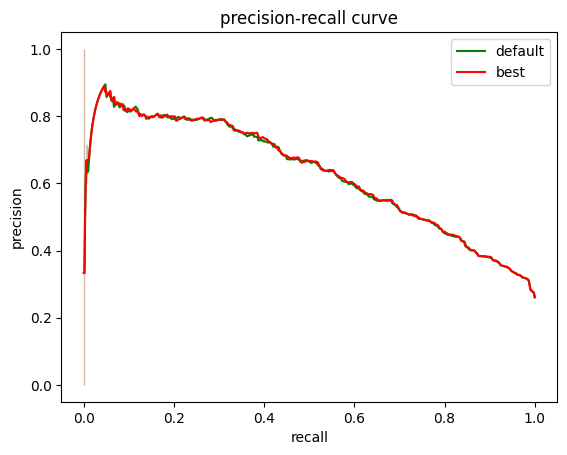

In [28]:
sns.lineplot(x=recall_default, y=precision_default, color = "green", label = "default")
sns.lineplot(x=recall_best, y=precision_best, color = "red", label = "best")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("precision-recall curve")
plt.show()

## ROC Curve & AUC

In [29]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [30]:
fpr_default, tpr_default, thresholds_default = roc_curve(y_test, proba_predictions_default)
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, proba_predictions_best)

#### Baseline Model ROC Curve

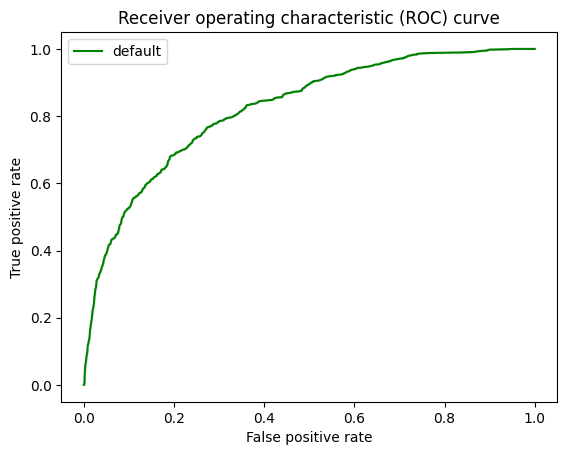

In [32]:
sns.lineplot(x=fpr_default, y=tpr_default, color = "green", label = "default")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Receiver operating characteristic (ROC) curve")
plt.legend()
plt.show()


#### Optimized Model ROC Curve

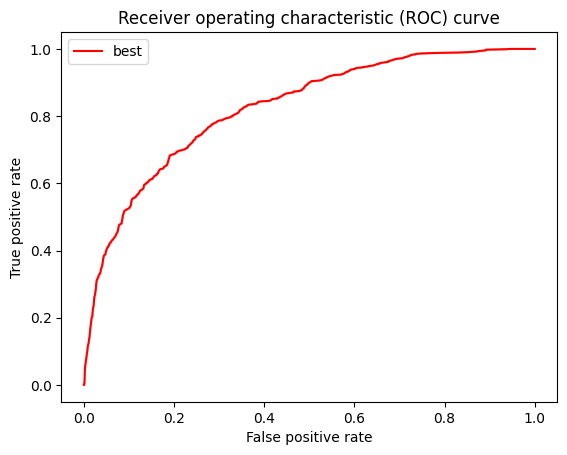

In [33]:
sns.lineplot(x = fpr_best, y = tpr_best, color = "red", label = "best")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Receiver operating characteristic (ROC) curve")
plt.legend()
plt.show()

In [40]:
auc_default = auc(fpr_default, tpr_default)
auc_best = auc(fpr_best, tpr_best)

print("Baseline AUC:", round(auc_default, 4))
print("Optimized AUC:", round(auc_best, 4))

Baseline AUC: 0.8228
Optimized AUC: 0.8236


## Feature Selection

### Top 5 Features

In [41]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

#top 5 features
selector = SelectKBest(f_classif, k=5)
selector.fit(X, y)
filter = selector.get_support()
top_5_features = X.columns[filter]

print("Best 5 features:")
print(top_5_features)

# Create datasets with selected features
new_X_train = X_train[top_5_features]
new_X_test = X_test[top_5_features]


# Train optimized model using selected features
model = LogisticRegression(C = best_C, max_iter=1000)
model.fit(new_X_train, y_train)


proba_predictions = model.predict_proba(new_X_test)[:,1]


fpr, tpr, thresholds = roc_curve(y_test, proba_predictions)
auc_result = auc(fpr, tpr)
print("Top 5 Features AUC:", round(auc_result, 4))


Best 5 features:
Index(['host_response_rate', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'review_scores_cleanliness'],
      dtype='str')
Top 5 Features AUC: 0.7972


## Model Persistence

In [37]:
import pickle
pkl_model_filename = "model_best.pkl"
pickle.dump(model_best, open(pkl_model_filename,"wb"))

In [39]:
with open(pkl_model_filename, "rb") as file:
    loaded_model = pickle.load(file)

predictions = loaded_model.predict(X_test)

print("Model successfully loaded.")
print("Sample predictions:", predictions[:10])

Model successfully loaded.
Sample predictions: [False False False False False  True False False False False]
